In [142]:
import numpy as np
import pandas as pd
import umap
import hdbscan
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import itertools
import seaborn as sns

In [124]:
df_path = r'C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\master_data\2016_to_2023_full_preprocessed_data_set.csv.gz'
df = pd.read_csv(df_path)

In [ ]:
def get_data() -> pd.DataFrame:
    demographic_cols = ['Gend3', 'Disab3', 'Age9', 'Eth7','NSSEC5']
    interested_cols = [
    'Educ6', 'MEMS7_ALL','year','IMD10', # Depravation
    'nchild', 'nadults', # Childcare responsibilties
    #'health', # General Health - variable is not in 2016/17
    'VolAny', # Has Volunteered
    'motivex2a', 'motivex2b', 'motivex2c', 'motivex2d', # Motivations
    'Motiva_POP', 'motivb_POP', 'motivc_POP', 'motivd_POP','motive_POP', 
    'inclus_a', 'inclus_b', 'inclus_c','comm1', 'comm2', # Social Cohesion
    'anxious',  'happy', 'lifesat', 'lone', 'worthw', # Life Emotions
    'indev', 'indevtry', # Different types of motivations
    'limfreti1', 'limfreti2', 'limfreti3', 'limfreti4',
    'limfreti5', 'limfreti6', 'limfreti7', 'limfreti8', # Limitations on free time
    'WorkStat10'# 'WorkStat5', 'WorkStat7' # Employment Status
    ]
    df_path = r'C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\master_data\2016_to_2023_full_preprocessed_data_set.csv.gz'
    df = pd.read_csv(df_path)
    df['VolAny'] = df['VolAny'].fillna(0.0)
    available = [col for col in interested_cols if col in df.columns]
    healthy_cols = missingness(80000, available, df)
    total_cols = demographic_cols + healthy_cols
    df = df[total_cols].dropna()
    return df

def missingness(health :int, available_cols:list, df : pd.DataFrame) -> list[str]:
    healthy_cols = []
    for j in available_cols:
        new = df[j].dropna()
        # print(f'Cols: {j}\nHas Size:{len(new)}')
        if len(new) > health:
            healthy_cols.append(j)
        continue
    return healthy_cols


In [125]:
demographic_cols = ['Gend3', 'Disab3', 'Age9', 'Eth7','NSSEC5']
categorical_cols = ['Gend3', 'Disab3','Eth7']
activity = ['MEMS7_ALL']
interested_cols = [
    'Educ6','IMD10', # Depravation

    'nchild', 'nadults', # Childcare responsibilties

    #'health', # General Health - variable is not in 2016/17

    'VolAny', # Has Volunteered

    'motivex2a', 'motivex2b', 'motivex2c', 'motivex2d', # Motivations
    'Motiva_POP', 'motivb_POP', 'motivc_POP', 'motivd_POP','motive_POP', 

    'inclus_a', 'inclus_b', 'inclus_c','comm1', 'comm2', # Social Cohesion

    'anxious',  'happy', 'lifesat', 'lone', 'worthw', # Life Emotions

    'indev', 'indevtry', # Different types of motivations

    'limfreti1', 'limfreti2', 'limfreti3', 'limfreti4',
    'limfreti5', 'limfreti6', 'limfreti7', 'limfreti8', # Limitations on free time

    'WorkStat10'# 'WorkStat5', 'WorkStat7' # Employment Status
    ]



In [126]:
available = [col for col in interested_cols if col in df.columns]
print(available)

['Educ6', 'IMD10', 'nchild', 'VolAny', 'Motiva_POP', 'motivb_POP', 'motivc_POP', 'motivd_POP', 'motive_POP', 'comm1', 'anxious', 'happy', 'lifesat', 'lone', 'worthw', 'indev', 'indevtry', 'WorkStat10']


In [127]:

def missingness(health :int, available_cols:list):
    df_path = r'C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\master_data\2016_to_2023_full_preprocessed_data_set.csv.gz'
    df = pd.read_csv(df_path)
    healthy_cols = []
    for j in available_cols:
        new = df[j].dropna()
        print(f'Cols: {j}\nHas Size:{len(new)}')
        if len(new) > health:
            healthy_cols.append(j)
        continue
    return healthy_cols
healthy_cols = missingness(80000, available)
healthy_cols

Cols: Educ6
Has Size:109663
Cols: IMD10
Has Size:117679
Cols: nchild
Has Size:115801
Cols: VolAny
Has Size:86767
Cols: Motiva_POP
Has Size:112852
Cols: motivb_POP
Has Size:113385
Cols: motivc_POP
Has Size:112463
Cols: motivd_POP
Has Size:110321
Cols: motive_POP
Has Size:7091
Cols: comm1
Has Size:40908
Cols: anxious
Has Size:40984
Cols: happy
Has Size:41007
Cols: lifesat
Has Size:41030
Cols: lone
Has Size:68070
Cols: worthw
Has Size:40922
Cols: indev
Has Size:40955
Cols: indevtry
Has Size:35167
Cols: WorkStat10
Has Size:114816


['Educ6',
 'IMD10',
 'nchild',
 'VolAny',
 'Motiva_POP',
 'motivb_POP',
 'motivc_POP',
 'motivd_POP',
 'WorkStat10']

cleaned has length: 67605


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


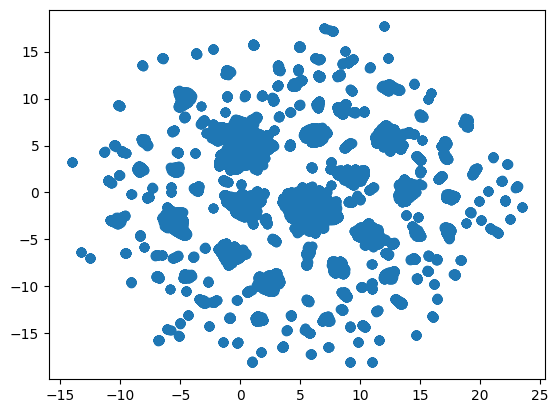

In [ ]:
healthy_cols = ['IMD10', 'nchild', 'VolAny', 'Motiva_POP', 'motivb_POP', 'motivc_POP', 'motivd_POP', 'WorkStat10']
def do_umap(df_values, random_state: int = 42):
    reduce = umap.UMAP(random_state = random_state)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_values)
    emb = reduce.fit_transform(X_scaled)
    return emb

df_path = r'C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\master_data\2016_to_2023_full_preprocessed_data_set.csv.gz'
df = pd.read_csv(df_path)
total_cols = demographic_cols + healthy_cols + activity
df_clean = df[total_cols].dropna()

print(f'cleaned has length: {len(df_clean)}')
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols)
exclude = ['MEMS7_ALL']
umap_cols = [c for c in df_encoded.columns if c not in exclude]
umap_df_values = df_encoded[umap_cols].values
mems = df_encoded['MEMS7_ALL'].values
emb = do_umap(umap_df_values)
plt.scatter(emb[:,0], emb[:,1])



Dataframe has length: 117679
idx: 0
v: 2016/17
New df has length: 19497


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Dataframe has length: 117679
idx: 1
v: 2017/18
New df has length: 16200


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Dataframe has length: 117679
idx: 2
v: 2018/19
New df has length: 16148


...

c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Dataframe has length: 117679
idx: 5
v: 2021/22
New df has length: 16382


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Dataframe has length: 117679
idx: 6
v: 2022/23
New df has length: 16748


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


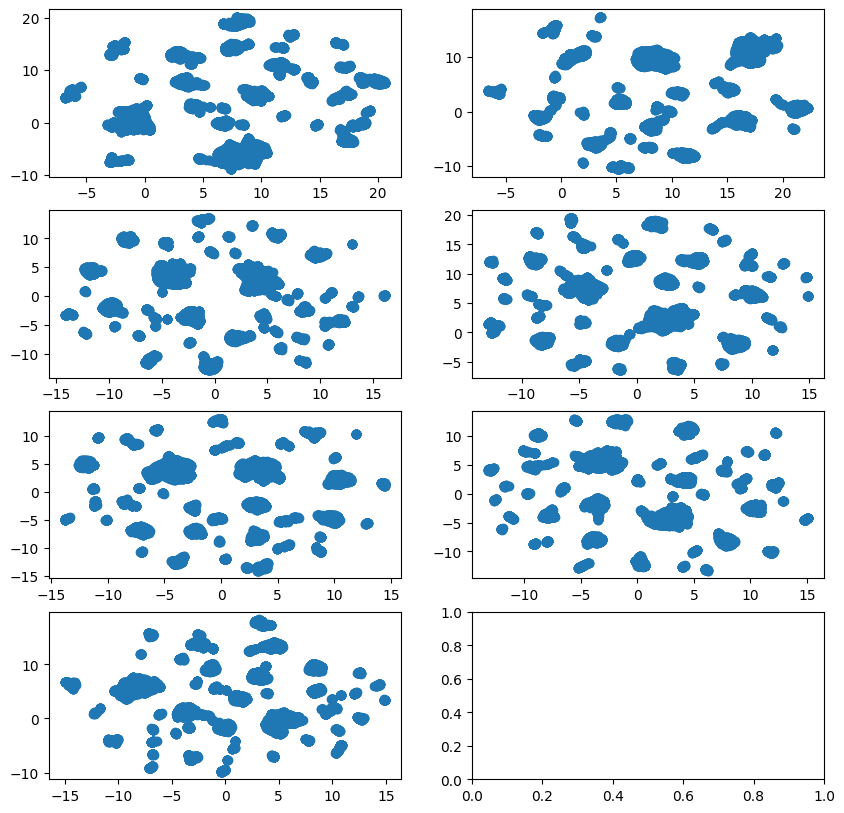

In [ ]:
healthy_cols = ['IMD10', 'nchild', 'VolAny', 'Motiva_POP', 'motivb_POP', 'motivc_POP', 'motivd_POP', 'WorkStat10']
fig, axes = plt.subplots(4, 2, figsize=(10, 10))
axes = axes.flatten()
df_path = r'C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\master_data\2016_to_2023_full_preprocessed_data_set.csv.gz'
df = pd.read_csv(df_path)
df['VolAny'] = df['VolAny'].fillna(0.0)
for idx, v in enumerate(df['year'].unique()):
    print(f'Dataframe has length: {len(df)}')
    print(f'idx: {idx}')
    print(f'v: {v}')
    new = df[df['year'] == v]
    print(f'New df has length: {len(new)}')
    total_cols = demographic_cols + healthy_cols + activity
    df_clean = new[total_cols].dropna()
    df_encoded = pd.get_dummies(df_clean, columns = categorical_cols)
    exclude = 'MEMS7_ALL'
    umap_cols = [col for col in df_encoded.columns if col != exclude]
    emb = do_umap(df_encoded[umap_cols].values)
    axes[idx].scatter(emb[:,0], emb[:,1])


In [93]:
df = get_data()
years = df['year'].unique().tolist()
df.head()
categorical_cols = ['Gend3', 'Disab3', 'Eth7']
df_2016 = df[df['year'] == years[0]]
df_2016_encoded = pd.get_dummies(df_2016, columns = categorical_cols)
exclude = ['MEMS7_ALL', 'year']
umap_cols_2016 = [c for c in df_2016_encoded.columns if c not in  exclude]
emb_2016 = do_umap(df_2016_encoded[umap_cols_2016].values)
clusterer = hdbscan.HDBSCAN(min_cluster_size=50, prediction_data=True)

labels_2016 = clusterer.fit_predict(emb_2016)
print(f'HDBSCAN has identified {len(set(labels_2016))} clusters.')
df_2017 = df[df['year'] == years[1]]
df_2017_encoded = pd.get_dummies(df_2017, columns = categorical_cols)
umap_cols_2017 = [c for c in df_2017_encoded.columns if c not in exclude]
emb_2017 = do_umap(df_2017_encoded[umap_cols_2017].values)
print(type(emb_2017))
print(emb_2017.shape)
test_labels, strengths = hdbscan.approximate_predict(clusterer, emb_2017)
print(test_labels)


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


HDBSCAN has identified 49 clusters.


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<class 'numpy.ndarray'>
(12407, 2)
[-1 -1 -1 ... -1  0 -1]


In [94]:
j = 0
for i in test_labels:
    if i == -1:
        j+=1
print(f'number of unclustered points: {j}')

number of unclustered points: 9098


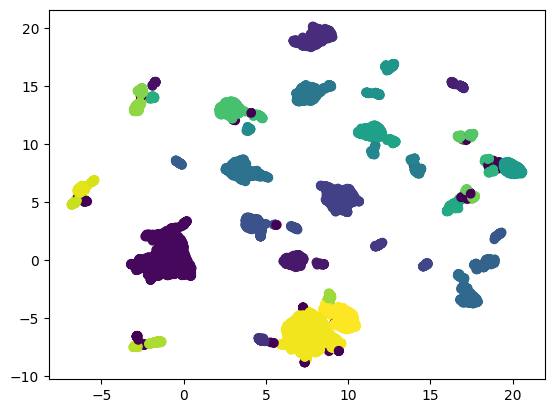

In [95]:
plt.scatter(emb_2016[:,0], emb_2016[:,1], c=labels_2016)

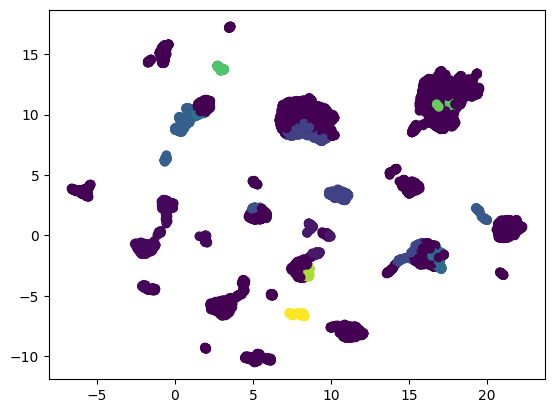

In [96]:
plt.scatter(emb_2017[:,0], emb_2017[:,1], c=test_labels)

In [97]:
len(emb_2016)

14823

In [ ]:
df = get_data()
years = df['year'].unique().tolist()
categorical_cols = [ 'Gend3', 'Disab3', 'Eth7']
exclude = ['MEMS7_ALL', 'year']
df_encoded_all = pd.get_dummies(df, columns = categorical_cols)
umap_cols = [c for c in df_encoded_all.columns if c not in  exclude]
df_2016 = df_encoded_all[df_encoded_all['year'] == years[0]]
X_2016 = df_2016[umap_cols].values
scaler = StandardScaler()
X_scaled_2016 = scaler.fit_transform(X_2016)
clusterer = hdbscan.HDBSCAN(min_cluster_size=50, prediction_data=True)
labels_2016 = clusterer.fit_predict(X_scaled_2016)
print(f'HDBSCAN has identified {len(set(labels_2016))} clusters.')
df_2017 = df_encoded_all[df_encoded_all['year'] == years[1]]
X_2017 = df_2017[umap_cols].values
X_scaled_2017 = scaler.transform(X_2017)
print(X_scaled_2016.shape)
print(X_scaled_2017.shape)
print(df_2016_encoded[umap_cols_2016].columns)
print(df_2017_encoded[umap_cols_2017].columns)
test_labels, strengths = hdbscan.approximate_predict(clusterer, X_scaled_2017)
print(test_labels)

HDBSCAN has identified 16 clusters.
(14656, 24)
(12258, 24)
Index(['Gend3', 'Age9', 'NSSEC5', 'IMD10', 'nchild', 'VolAny', 'Motiva_POP',
       'motivb_POP', 'motivc_POP', 'motivd_POP', 'WorkStat10', 'Disab3_1.0',
       'Disab3_2.0', 'Disab3_3.0', 'Eth7_1.0', 'Eth7_2.0', 'Eth7_3.0',
       'Eth7_4.0', 'Eth7_5.0', 'Eth7_6.0', 'Eth7_7.0'],
      dtype='str')
Index(['Gend3', 'Age9', 'NSSEC5', 'IMD10', 'nchild', 'VolAny', 'Motiva_POP',
       'motivb_POP', 'motivc_POP', 'motivd_POP', 'WorkStat10', 'Disab3_1.0',
       'Disab3_2.0', 'Disab3_3.0', 'Eth7_1.0', 'Eth7_2.0', 'Eth7_3.0',
       'Eth7_4.0', 'Eth7_5.0', 'Eth7_6.0', 'Eth7_7.0'],
      dtype='str')
[14 -1 12 ...  7  4  7]


In [148]:
j = 0
for i in test_labels:
    if i == -1:
        j +=1
print(j)

2691


In [149]:
df_2016 = df[df['year']== years[0]]
df_2016['labels'] = labels_2016
eth_2016 = df_2016.groupby(['labels', 'Eth7'])['Eth7'].sum()
eth_2016

labels  Eth7
-1      1.0     2005.0
        2.0     1916.0
        3.0     1635.0
        4.0      548.0
        6.0       36.0
        7.0       14.0
 0      5.0     1475.0
 1      7.0     2681.0
 2      6.0     2604.0
 3      4.0     3252.0
 4      1.0      892.0
        2.0      178.0
        3.0       51.0
 5      3.0     3867.0
 6      2.0      142.0
 7      1.0      310.0
 8      1.0      397.0
 9      2.0     1004.0
 10     2.0     1602.0
 11     1.0      294.0
 12     1.0     1771.0
 13     1.0      311.0
 14     1.0     2334.0
Name: Eth7, dtype: float64

In [150]:
df_2016.columns

Index(['Gend3', 'Disab3', 'Age9', 'Eth7', 'NSSEC5', 'Educ6', 'MEMS7_ALL',
       'year', 'IMD10', 'nchild', 'VolAny', 'Motiva_POP', 'motivb_POP',
       'motivc_POP', 'motivd_POP', 'WorkStat10', 'labels'],
      dtype='str')

In [151]:
profiles_2016 = df_2016.groupby('labels').agg({
    'Gend3' : 'mean',
    'Disab3' : 'mean',
    'Age9' : 'mean',
    'NSSEC5' : 'mean',
    'IMD10' : 'mean',
    'nchild' : 'mean',
    'VolAny' : 'mean',
    'Motiva_POP' : 'mean',
    'motivb_POP' : 'mean',
    'motivc_POP' : 'mean',
    'motivd_POP' : 'mean',
    'WorkStat10' : 'mean',
    'Educ6' : 'mean',
    'MEMS7_ALL' : 'mean'
})

In [152]:
df_2017 = df[df['year'] == years[1]]
df_2017['labels'] = test_labels
eth_2017 = df_2017.groupby(['labels', 'Eth7'])['Eth7'].sum()
eth_2017

labels  Eth7
-1      1.0     1363.0
        2.0     1618.0
        3.0     1185.0
        4.0      476.0
        6.0       24.0
        7.0        7.0
 0      5.0     1240.0
 1      7.0     2177.0
 2      6.0     2340.0
 3      4.0     2672.0
 4      1.0      694.0
        2.0      120.0
        3.0       57.0
 5      3.0     3159.0
 6      2.0      118.0
 7      1.0      291.0
 8      1.0      336.0
 9      2.0      984.0
 10     2.0     1508.0
 11     1.0      258.0
 12     1.0     1649.0
 13     1.0      281.0
 14     1.0     2004.0
Name: Eth7, dtype: float64

In [153]:
profiles_2017 = df_2017.groupby('labels').agg({
    'Gend3' : 'mean',
    'Disab3' : 'mean',
    'Age9' : 'mean',
    'NSSEC5' : 'mean',
    'IMD10' : 'mean',
    'nchild' : 'mean',
    'VolAny' : 'mean',
    'Motiva_POP' : 'mean',
    'motivb_POP' : 'mean',
    'motivc_POP' : 'mean',
    'motivd_POP' : 'mean',
    'WorkStat10' : 'mean',
    'Educ6' : 'mean',
    'MEMS7_ALL' : 'mean'
})

In [154]:
profile_scaler = StandardScaler()
sorted_profiles_2016 = profiles_2016.sort_values('MEMS7_ALL')
heat_2016 = profile_scaler.fit_transform(sorted_profiles_2016)
sorted_profiles_2017 = profiles_2017.sort_values('MEMS7_ALL')
heat_2017 = profile_scaler.transform(sorted_profiles_2017)

Text(0.5, 1.0, '2016 cluster profiles')

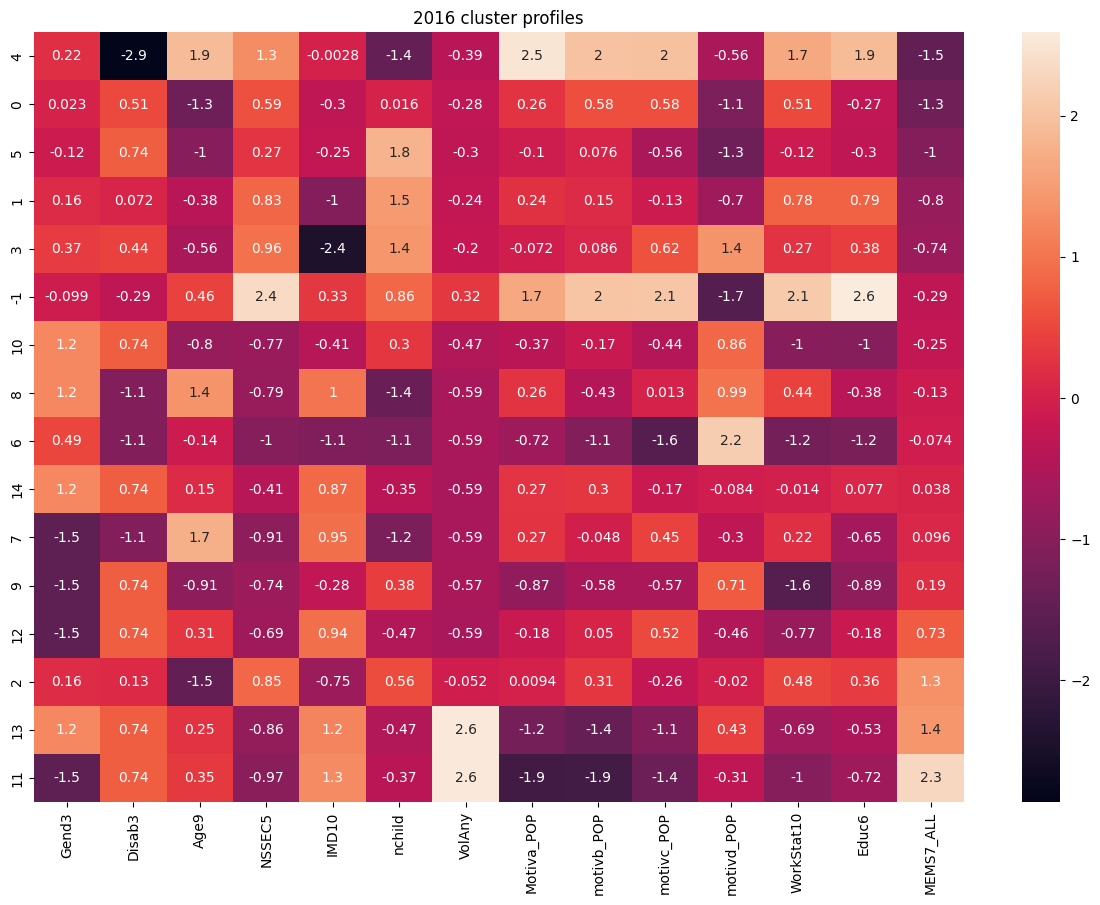

In [155]:
plt.figure(figsize=(15,10))
sns.heatmap(
    heat_2016,
    annot=True,
    xticklabels = sorted_profiles_2016.columns,
    yticklabels = sorted_profiles_2016.index)
plt.title('2016 cluster profiles')

Text(0.5, 1.0, '2017 cluster profiles')

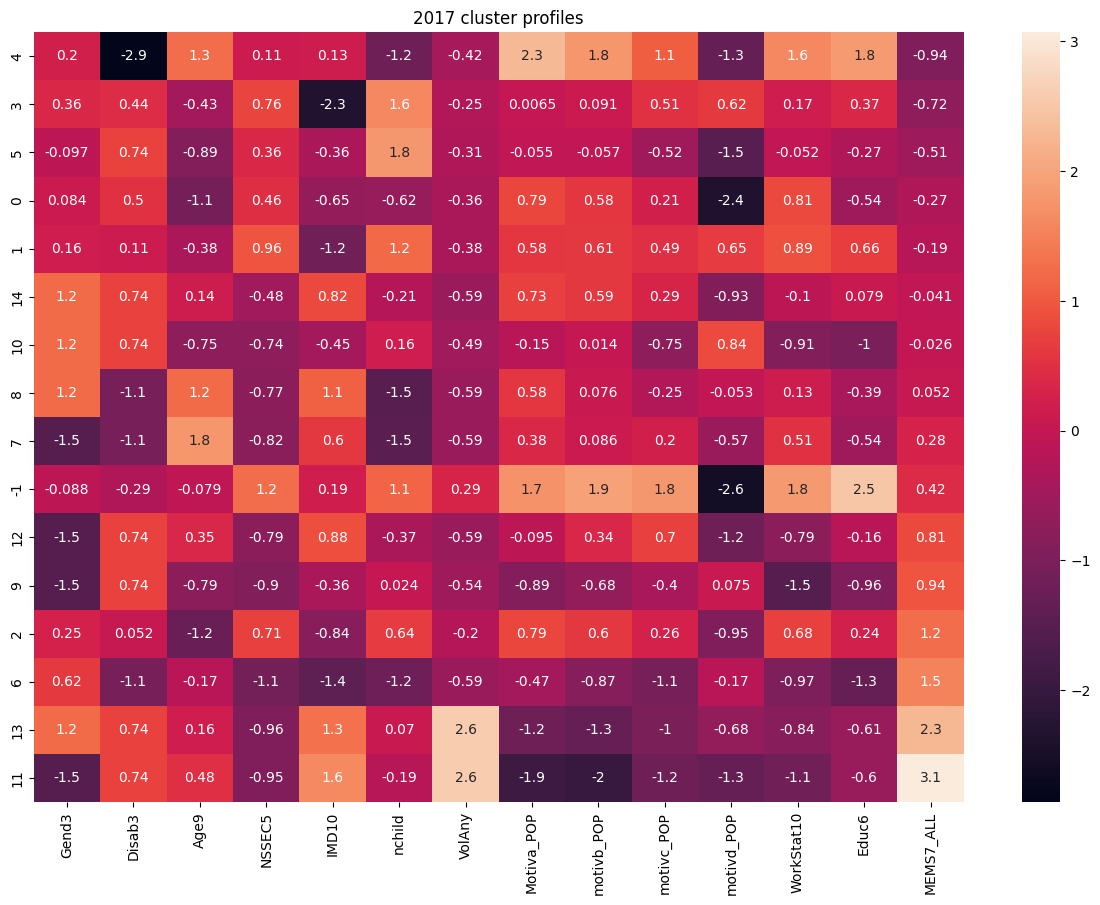

In [156]:
plt.figure(figsize=(15,10))
sns.heatmap(
    heat_2017,
    annot=True,
    xticklabels = sorted_profiles_2017.columns,
    yticklabels = sorted_profiles_2017.index)
plt.title('2017 cluster profiles')

Dataframe has length: 86089
idx: 0
v: 2016/17
New df has length: 14656


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Dataframe has length: 86089
idx: 1
v: 2017/18
New df has length: 12258
Dataframe has length: 86089
idx: 2
v: 2018/19
New df has length: 12145
Dataframe has length: 86089
idx: 3
v: 2019/20
New df has length: 9763
Dataframe has length: 86089
idx: 4
v: 2020/21
New df has length: 12472
Dataframe has length: 86089
idx: 5
v: 2021/22
New df has length: 12308
Dataframe has length: 86089
idx: 6
v: 2022/23
New df has length: 12487


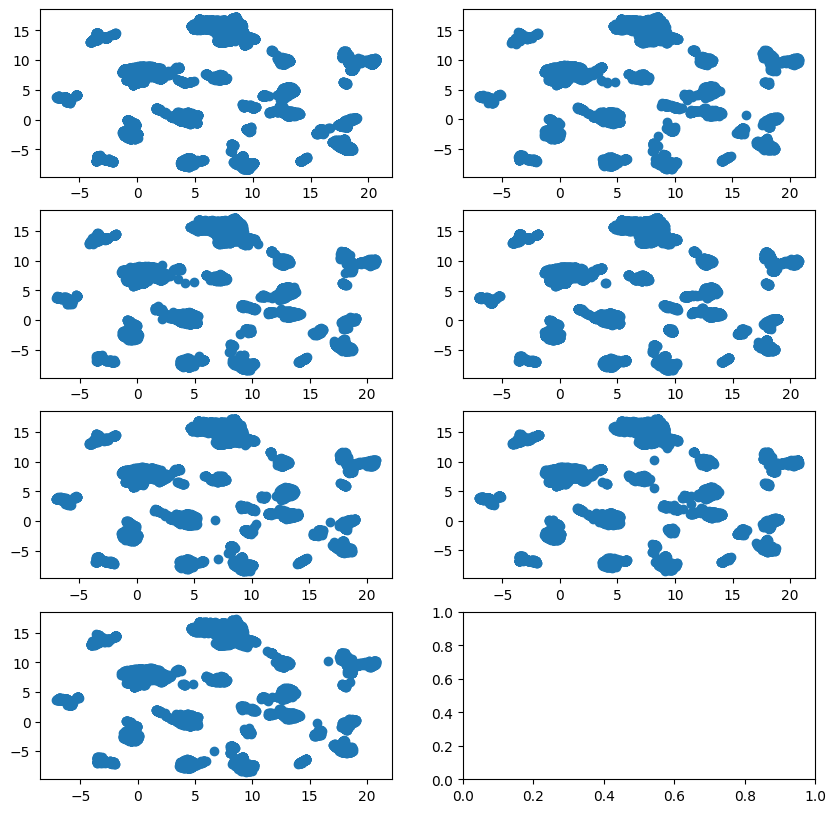

In [158]:
categorical_cols = ['Gend3', 'Disab3', 'Eth7']
fig, axes = plt.subplots(4, 2, figsize=(10, 10))
axes = axes.flatten()
df = get_data()
df_encoded = pd.get_dummies(df, columns = categorical_cols)
scaler = StandardScaler()
reducer = umap.UMAP(random_state=42)
for idx, v in enumerate(df_encoded['year'].unique()):
    print(f'Dataframe has length: {len(df)}')
    print(f'idx: {idx}')
    print(f'v: {v}')
    new = df_encoded[df_encoded['year'] == v]
    print(f'New df has length: {len(new)}')
    exclude = ['MEMS7_ALL', 'year']
    umap_cols = [col for col in new.columns if col not in exclude]
    if idx == 0:
        X_scaled = scaler.fit_transform(new[umap_cols].values)
        emb = reducer.fit_transform(X_scaled)
        axes[idx].scatter(emb[:,0], emb[:,1])
        continue
    X_scaled = scaler.transform(new[umap_cols].values)
    emb = reducer.transform(X_scaled)
    axes[idx].scatter(emb[:,0], emb[:,1])


In [171]:
categorical_cols = ['Gend3', 'Disab3', 'Eth7']
df = get_data()
df_encoded = pd.get_dummies(df, columns = categorical_cols)
scaler = StandardScaler()
reducer = umap.UMAP(random_state=42)
clusterer = hdbscan.HDBSCAN(min_cluster_size=150, prediction_data=True)
years = list(df_encoded['year'].unique())
df_encoded_2016 = df_encoded[df_encoded['year'] == years[0]]
exclude = ['year', 'MEMS7_ALL']
umap_cols = [c for c in df_encoded.columns if c not in exclude]
X = df_encoded_2016[umap_cols].values
X_scaled = scaler.fit_transform(X)
emb = reducer.fit_transform(X_scaled)
labels = clusterer.fit_predict(emb)
df_encoded_2016['labels'] = labels
df_encoded_2016['umap_x'] = emb[:,0]
df_encoded_2016['umap_y'] = emb[:,1]

c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


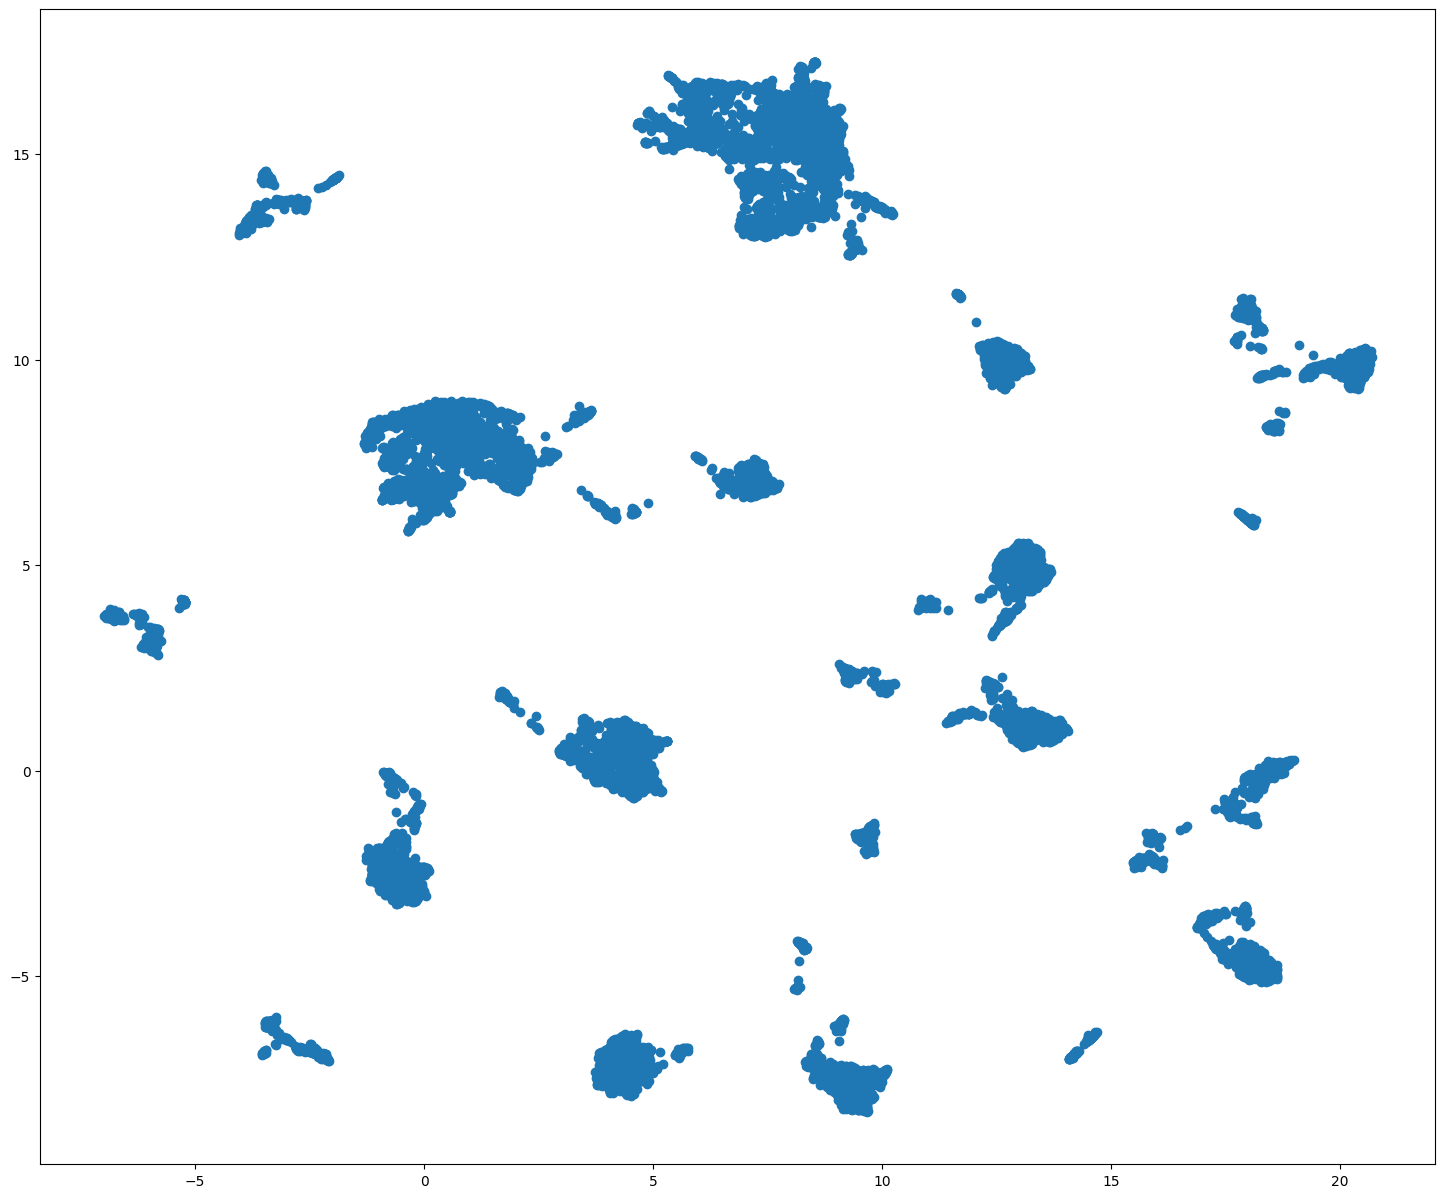

In [172]:
plt.figure(figsize=(18,15))
plt.scatter(emb[:,0], emb[:,1])

In [173]:
sorted(df_encoded_2016['labels'].unique())

[np.int64(-1),
 np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19)]

(np.float64(-8.384394097328187),
 np.float64(22.07633583545685),
 np.float64(-9.578630065917968),
 np.float64(18.52653274536133))

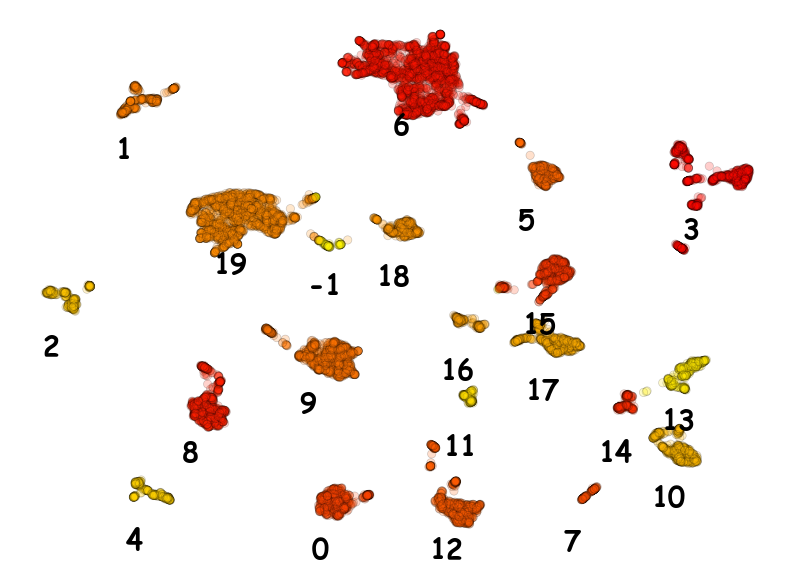

In [176]:
plt.figure(figsize=(10,7))
x_means = []
y_means = []
for l in sorted(df_encoded_2016['labels'].unique()):
    l = int(l)
    mean = df_encoded_2016[df_encoded_2016['labels'] == l]
    x_means.append(mean['umap_x'].mean())
    y_means.append(mean['umap_y'].mean())

sns.scatterplot(
    x=emb[:,0],
    y=emb[:,1],
    hue=labels.astype(str),
    palette='autumn', # Wistia
    legend = False,
    alpha=0.2,
    edgecolor='black'
)
for idx, l in enumerate(sorted(df_encoded_2016['labels'].unique())):
    plt.text(x_means[idx] - 1, y_means[idx] - 3,s=f'{l}',
                 fontsize=20,
                 weight='bold',
                 fontname ='cursive')
"""
for idx, l in enumerate(sorted(df_encoded_2016['labels'].unique())):
    if l == 16 or l == 15 or l == 1:
        plt.text(x_means[idx] - 1, y_means[idx] - 3,s=f'{l}',
                 fontsize=20,
                 weight='bold',
                 fontname ='cursive')
    elif l == 6 or l == 5:
        plt.text(x_means[idx], y_means[idx]-3.5, s=f'{l}',
                 fontsize=20,
                 weight='bold',
                 fontname ='cursive')
    else:
        plt.text(x_means[idx] - 2, y_means[idx] + 2,s=f'{l}',
                 fontsize=20,
                 weight='bold',
                 fontname = 'cursive')
"""
plt.axis('off')